In [1]:
import pickle
import pandas as pd

In [2]:
model_path_prefix  = '../2_model_development/'
data_prefix = '../3_model_evaluation/'
non_feature_cols = ['SMILES', 'MP', 'Type', 'Ro5']
model_types = ['RF', 'XGB', 'LGB']

In [3]:
import numpy as np
from sklearn.ensemble import RandomForestRegressor
import lightgbm as lgb
import xgboost as xgb


def model_confidence_analysis(model, test_data, train_data=None,
                               non_feature_cols=None):
    """
    Compute prediction uncertainty and attach results to test_data.

    Parameters
    ----------
    model            : fitted estimator – RF, LGBMRegressor, or XGBRegressor
    test_data        : pd.DataFrame with feature columns + non_feature_cols
    train_data       : pd.DataFrame – required for LGB / XGB quantile approach
    non_feature_cols : list of non-feature column names
                       (default: ['SMILES', 'MP', 'Type', 'Ro5'])

    Returns
    -------
    result : pd.DataFrame (copy of test_data) with added columns:
             RF       → 'uncertainty'  = std of individual tree predictions
             LGB/XGB  → 'lower' (q10), 'upper' (q90),
                         'uncertainty' = upper - lower
    """
    if non_feature_cols is None:
        non_feature_cols = ['SMILES', 'MP', 'Type', 'Ro5', 'MP_pred']

    feature_cols = [c for c in test_data.columns if c not in non_feature_cols]
    X_test = test_data[feature_cols]
    result = test_data.copy()

    # ── Random Forest ─────────────────────────────────────────────────────────
    if isinstance(model, RandomForestRegressor):
        tree_preds = np.array([tree.predict(X_test) for tree in model.estimators_])
        result['uncertainty'] = tree_preds.std(axis=0)

    # ── LightGBM ──────────────────────────────────────────────────────────────
    elif isinstance(model, lgb.LGBMRegressor):
        if train_data is None:
            raise ValueError("train_data is required for LGB quantile confidence analysis.")

        X_train = train_data[feature_cols]
        y_train = train_data['MP']

        params = model.get_params()
        params.pop('objective', None)   # will be overridden below

        lower_model = lgb.LGBMRegressor(**params, objective='quantile', alpha=0.1)
        lower_model.fit(X_train, y_train)

        upper_model = lgb.LGBMRegressor(**params, objective='quantile', alpha=0.9)
        upper_model.fit(X_train, y_train)

        result['lower'] = lower_model.predict(X_test)
        result['upper'] = upper_model.predict(X_test)
        result['uncertainty'] = result['upper'] - result['lower']

    # ── XGBoost ───────────────────────────────────────────────────────────────
    elif isinstance(model, xgb.XGBRegressor):
        if train_data is None:
            raise ValueError("train_data is required for XGB quantile confidence analysis.")

        X_train = train_data[feature_cols].values
        y_train = train_data['MP'].values

        # Pinball (quantile) loss – works on all XGBoost versions
        def _pinball_obj(alpha):
            def obj(y_pred, dtrain):
                y_true = dtrain.get_label()
                error  = y_true - y_pred
                grad   = np.where(error >= 0, -alpha, 1.0 - alpha)
                hess   = np.ones_like(y_pred)
                return grad, hess
            return obj

        # Map sklearn wrapper params → native xgb params
        skl_params = model.get_params()
        n_estimators = skl_params.get('n_estimators', 100)

        _param_map = {
            'max_depth':          'max_depth',
            'learning_rate':      'eta',
            'subsample':          'subsample',
            'colsample_bytree':   'colsample_bytree',
            'colsample_bylevel':  'colsample_bylevel',
            'colsample_bynode':   'colsample_bynode',
            'min_child_weight':   'min_child_weight',
            'gamma':              'gamma',
            'reg_alpha':          'alpha',
            'reg_lambda':         'lambda',
            'n_jobs':             'nthread',
            'random_state':       'seed',
            'max_delta_step':     'max_delta_step',
            'scale_pos_weight':   'scale_pos_weight',
        }
        native_params = {'objective': 'reg:squarederror', 'verbosity': 0}
        for skl_key, xgb_key in _param_map.items():
            val = skl_params.get(skl_key)
            if val is not None:
                native_params[xgb_key] = val

        dtrain = xgb.DMatrix(X_train, label=y_train)
        dtest  = xgb.DMatrix(X_test.values)

        lower_booster = xgb.train(native_params, dtrain,
                                   num_boost_round=n_estimators,
                                   obj=_pinball_obj(0.1),
                                   verbose_eval=False)
        upper_booster = xgb.train(native_params, dtrain,
                                   num_boost_round=n_estimators,
                                   obj=_pinball_obj(0.9),
                                   verbose_eval=False)

        result['lower'] = lower_booster.predict(dtest)
        result['upper'] = upper_booster.predict(dtest)
        result['uncertainty'] = result['upper'] - result['lower']

    else:
        raise TypeError(
            f"Unsupported model type: {type(model).__name__}. "
            "Expected RandomForestRegressor, LGBMRegressor, or XGBRegressor."
        )

    return result


In [ ]:
import joblib


for model_type in ['RF', 'LGB']:

    data = pd.read_parquet(f'../0_data/processed_data/data_with_selected_features_{model_type}_scaled.parquet')

    train_df = data[data['Type'] == 'Train']
    test_df = data[data['Type'] == 'Test']

    model = joblib.load(f'{model_path_prefix}best_model_{model_type}.joblib')

    test_df['MP_pred'] = model.predict(test_df.drop(columns=non_feature_cols))
    test_df['AE'] = (test_df['MP'] - test_df['MP_pred']).abs()

    results = model_confidence_analysis(model=model, test_data=test_df, train_data=train_df,
                                non_feature_cols= ['SMILES', 'MP', 'Type', 'Ro5', 'MP_pred', 'AE'])
    
    results.to_csv(f'model_confidence_results_{model_type}.csv', index=False)

/Users/zeqing/opt/anaconda3/envs/melting_point/lib/python3.11/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/Users/zeqing/opt/anaconda3/envs/melting_point/lib/python3.11/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/Users/zeqing/opt/anaconda3/envs/melting_point/lib/python3.11/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/Users/zeqing/opt/anaconda3/envs/melting_point/lib/python3.11/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/Users/zeqing/opt/anaconda3/envs/melting_point/lib/python3.11/site-packages/sklearn/utils/validation.py:2742: UserWarnin

AttributeError: 'XGBModel' object has no attribute 'feature_weights'

In [5]:
LGB_results = pd.read_csv('model_confidence_results_LGB.csv')
LGB_results


,SMILES,MP,Type,Ro5,RDKit_TPSA,RDKit_FpDensityMorgan3,RDKit_NumRotatableBonds,RDKit_VSA_EState4,RDKit_BertzCT,RDKit_BCUT2D_MRHI,...,RDKit_fr_imidazole,RDKit_Chi3n,RDKit_PEOE_VSA2,RDKit_ExactMolWt,RDKit_EState_VSA9,MP_pred,AE,lower,upper,uncertainty
0,[O-][N+](=O)c1c(C)c(C(=O)C)c(c(c1C(C)(C)C)[N+]...,135.5,Test,1,1.469587,-1.430020,0.035715,-0.979718,0.442559,-0.352389,...,-0.13318,0.296533,3.254063,0.406609,-0.817685,114.763238,20.736762,85.993976,140.022768,54.028791
1,CN(NC(=O)CCC(=O)O)C,154.5,Test,1,0.507304,0.089508,0.337194,0.224807,-1.085124,-0.486108,...,-0.13318,-0.922830,1.636929,-0.857210,-0.327823,153.340176,1.159824,123.196481,187.393112,64.196631
2,CCCCc1ccc(cc1)NC(=O)Oc1ccc(cc1)OC,143.0,Test,1,-0.122990,0.002796,0.940151,0.072728,0.360855,-0.444646,...,-0.13318,0.241667,0.069922,0.454041,0.091116,125.087732,17.912268,76.179944,132.149336,55.969391
3,OC(=O)COCCN1C(=O)c2c(C1=O)cccc2,128.0,Test,1,0.914654,-0.006839,0.638672,-0.362995,-0.020869,-0.208970,...,-0.13318,-0.114470,1.551958,-0.018237,0.126577,123.513925,4.486075,105.904017,186.344917,80.440900
4,CCCCCCCCCCCCCCC,10.0,Test,1,-1.480634,-2.847146,2.749022,-0.626227,-1.323539,-1.374480,...,-0.13318,0.201356,-0.789161,-0.365346,-0.817685,21.989887,11.989887,13.905502,29.804528,15.899026
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5161,c1ccc2c(c1)c1cc3ccc4c(c3nc1cc2)cccc4,226.0,Test,1,-1.112677,-0.430765,-0.868720,0.124226,1.976777,-0.259144,...,-0.13318,0.791899,-0.789161,0.265017,-0.339579,217.182728,8.817272,157.420850,229.526206,72.105356
5162,COc1cc(OC)cc(c1C#N)OC,142.0,Test,1,-0.011090,-0.839552,0.035715,-0.496212,-0.462579,-0.642258,...,-0.13318,-0.475385,-0.789161,-0.546159,1.050281,86.323559,55.676441,61.037504,113.769961,52.732456
5163,OCCCCCCCCCCc1ccccc1,36.0,Test,1,-0.903150,-0.879629,2.146065,-0.111926,-0.753977,-0.927824,...,-0.13318,0.205908,-0.789161,-0.158401,-0.327823,18.649811,17.350189,19.182263,42.539399,23.357136
5164,Clc1c2OC3Cc4c(C3Oc2c(c(c1Cl)Cl)Cl)cccc4,159.0,Test,1,-0.953676,-0.158241,-0.868720,0.180255,0.923148,0.004288,...,-0.13318,0.500622,-0.789161,1.027089,4.542560,167.820289,8.820289,139.449240,175.459090,36.009851


In [6]:
RF_results = pd.read_csv('model_confidence_results_RF.csv')
RF_results

,SMILES,MP,Type,Ro5,RDKit_TPSA,RDKit_BertzCT,RDKit_NumHDonors,RDKit_RingCount,RDKit_NHOHCount,RDKit_FractionCSP3,...,RDKit_EState_VSA2,RDKit_SMR_VSA5,RDKit_VSA_EState8,RDKit_EState_VSA4,RDKit_SMR_VSA7,RDKit_SlogP_VSA8,RDKit_SlogP_VSA1,MP_pred,AE,uncertainty
0,[O-][N+](=O)c1c(C)c(C(=O)C)c(c(c1C(C)(C)C)[N+]...,135.5,Test,1,1.469587,0.442559,-0.857454,-0.677491,-0.839721,0.679669,...,2.630821,0.998128,2.270969,-0.914871,0.188151,-0.467993,-0.769670,112.748222,22.751778,40.644007
1,CN(NC(=O)CCC(=O)O)C,154.5,Test,1,0.507304,-1.085124,0.949337,-1.446897,0.694148,1.242283,...,1.070382,-0.226208,-0.648216,-0.914871,-1.420751,-0.467993,0.285544,144.329085,10.170915,45.223132
2,CCCCc1ccc(cc1)NC(=O)Oc1ccc(cc1)OC,143.0,Test,1,-0.122990,0.360855,0.045942,0.091915,-0.072787,-0.070483,...,-0.895806,0.252697,0.041357,0.598021,0.627921,-0.467993,2.106807,119.470407,23.529593,35.543748
3,OC(=O)COCCN1C(=O)c2c(C1=O)cccc2,128.0,Test,1,0.914654,-0.020869,0.045942,0.091915,-0.072787,-0.164252,...,1.722377,-0.687065,-0.767109,-0.499754,-0.080365,-0.467993,-0.769670,143.421273,15.421273,45.860851
4,CCCCCCCCCCCCCCC,10.0,Test,1,-1.480634,-1.323539,-0.857454,-1.446897,-0.839721,2.367511,...,-0.895806,2.805458,0.804767,-0.914871,-1.420751,-0.467993,-0.769670,27.146626,17.146626,8.805522
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5161,c1ccc2c(c1)c1cc3ccc4c(c3nc1cc2)cccc4,226.0,Test,1,-1.112677,1.976777,-0.857454,2.400134,-0.839721,-1.008173,...,-0.895806,-0.687065,-0.648216,0.019870,1.565954,5.943750,-0.769670,206.785400,19.214600,42.748318
5162,COc1cc(OC)cc(c1C#N)OC,142.0,Test,1,-0.011090,-0.462579,-0.857454,-0.677491,-0.839721,0.004532,...,-0.895806,-0.687065,-0.648216,-0.914871,-0.750558,-0.467993,1.994022,74.350371,67.649629,24.198373
5163,OCCCCCCCCCCc1ccccc1,36.0,Test,1,-0.903150,-0.753977,0.045942,-0.677491,-0.072787,1.101629,...,-0.895806,1.386791,-0.534476,-0.370904,-0.061319,-0.467993,-0.769670,37.741411,1.741411,15.694169
5164,Clc1c2OC3Cc4c(C3Oc2c(c(c1Cl)Cl)Cl)cccc4,159.0,Test,1,-0.953676,0.923148,-0.857454,1.630727,-0.839721,-0.333036,...,2.491332,-0.018522,-0.648216,0.100427,0.680507,-0.467993,1.072791,160.890880,1.890880,45.755670


In [11]:
XGB_results = pd.read_csv('model_confidence_results_XGB.csv')
XGB_results

FileNotFoundError: [Errno 2] No such file or directory: 'model_confidence_results_XGB.csv'

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# make the following code as a def with the data as the input and the model name as the title of the plot
def plot_uncertainty_vs_ae(data, model_name):

    sns.scatterplot(data=data, x='uncertainty', y='AE')
    # add correlation coefficient
    corr = data['uncertainty'].corr(data['AE'])
    plt.title(f'{model_name}: AE vs Uncertainty (corr={corr:.2f})')


    # pearson corr to check which columns in the data associated with higher uncertainty
    corr_matrix = data.drop(columns = ['SMILES', 'Type']).corr()
    uncertainty_corr = corr_matrix['uncertainty'].drop('uncertainty').sort_values(ascending=False)
    # print top 10 features most correlated with uncertainty
    print("Top 10 features most correlated with uncertainty:")
    print(uncertainty_corr.head(10))

    # print top 10 features most negatively correlated with uncertainty
    print("\nTop 10 features most negatively correlated with uncertainty:")
    print(uncertainty_corr.tail(10))

    # print the mean AE and uncertainty for Ro5 vs bRo5 compounds
    for ro5_status in [0, 1]:
        subset = data[data['Ro5'] == ro5_status]
        mean_ae = subset['AE'].mean()
        mean_uncertainty = subset['uncertainty'].mean()
        print(f"Ro5={ro5_status}: Mean AE = {mean_ae:.2f}, Mean Uncertainty = {mean_uncertainty:.2f}")


Top 10 features most correlated with uncertainty:
MP_pred                 0.544227
MP                      0.472835
RDKit_BertzCT           0.332587
RDKit_RingCount         0.327351
AE                      0.306444
RDKit_HeavyAtomMolWt    0.285103
RDKit_AvgIpc            0.274090
RDKit_NumHeteroatoms    0.270585
RDKit_TPSA              0.265780
RDKit_Chi3v             0.254481
Name: uncertainty, dtype: float64

Top 10 features most negatively correlated with uncertainty:
RDKit_qed                -0.104753
RDKit_BCUT2D_MWHI        -0.109075
Ro5                      -0.158825
RDKit_FpDensityMorgan3   -0.164876
RDKit_BCUT2D_CHGLO       -0.188940
RDKit_FpDensityMorgan2   -0.193508
RDKit_FpDensityMorgan1   -0.201146
RDKit_BalabanJ           -0.218162
RDKit_HallKierAlpha      -0.255810
RDKit_BCUT2D_LOGPLOW     -0.258657
Name: uncertainty, dtype: float64
Ro5=0: Mean AE = 40.03, Mean Uncertainty = 48.72
Ro5=1: Mean AE = 29.46, Mean Uncertainty = 34.80


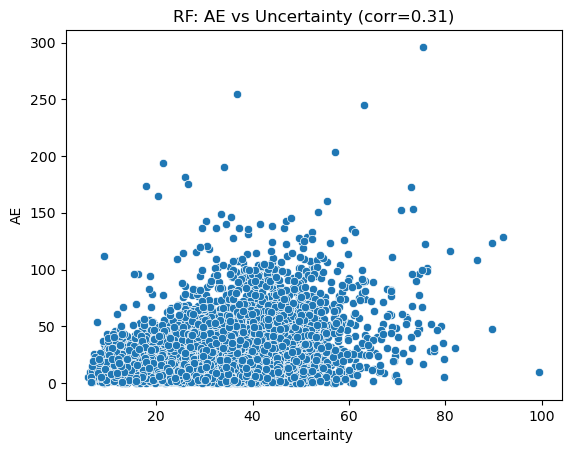

In [8]:
plot_uncertainty_vs_ae(RF_results, 'RF')


Top 10 features most correlated with uncertainty:
upper                0.537350
MP_pred              0.399187
MP                   0.360101
AE                   0.249785
RDKit_SlogP_VSA8     0.190243
RDKit_RingCount      0.185234
lower                0.183101
MACCS_142            0.181384
RDKit_EState_VSA8    0.175269
MACCS_101            0.173889
Name: uncertainty, dtype: float64

Top 10 features most negatively correlated with uncertainty:
RDKit_BCUT2D_LOGPLOW      -0.114986
RDKit_VSA_EState7         -0.138660
RDKit_SMR_VSA5            -0.139631
RDKit_Kappa2              -0.141610
RDKit_SlogP_VSA5          -0.146265
RDKit_EState_VSA5         -0.147706
MACCS_155                 -0.167799
RDKit_Phi                 -0.176311
RDKit_NumRotatableBonds   -0.183579
RDKit_fr_unbrch_alkane    -0.256206
Name: uncertainty, dtype: float64
Ro5=0: Mean AE = 37.64, Mean Uncertainty = 76.59
Ro5=1: Mean AE = 25.88, Mean Uncertainty = 62.98


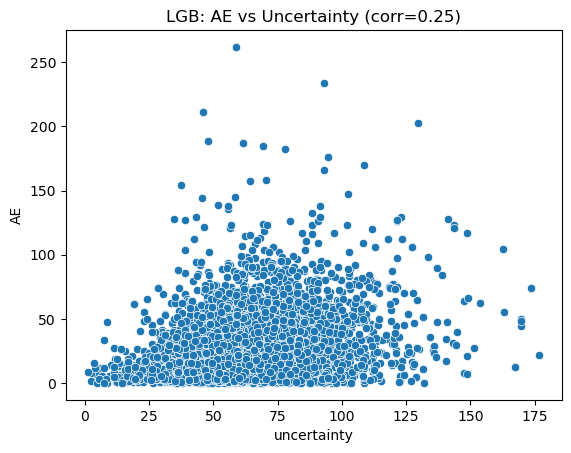

In [9]:
plot_uncertainty_vs_ae(LGB_results, 'LGB')


Top 10 features most correlated with uncertainty:
upper                0.537350
MP_pred              0.399187
MP                   0.360101
AE                   0.249785
RDKit_SlogP_VSA8     0.190243
RDKit_RingCount      0.185234
lower                0.183101
MACCS_142            0.181384
RDKit_EState_VSA8    0.175269
MACCS_101            0.173889
Name: uncertainty, dtype: float64

Top 10 features most negatively correlated with uncertainty:
RDKit_BCUT2D_LOGPLOW      -0.114986
RDKit_VSA_EState7         -0.138660
RDKit_SMR_VSA5            -0.139631
RDKit_Kappa2              -0.141610
RDKit_SlogP_VSA5          -0.146265
RDKit_EState_VSA5         -0.147706
MACCS_155                 -0.167799
RDKit_Phi                 -0.176311
RDKit_NumRotatableBonds   -0.183579
RDKit_fr_unbrch_alkane    -0.256206
Name: uncertainty, dtype: float64
Ro5=0: Mean AE = 37.64, Mean Uncertainty = 76.59
Ro5=1: Mean AE = 25.88, Mean Uncertainty = 62.98


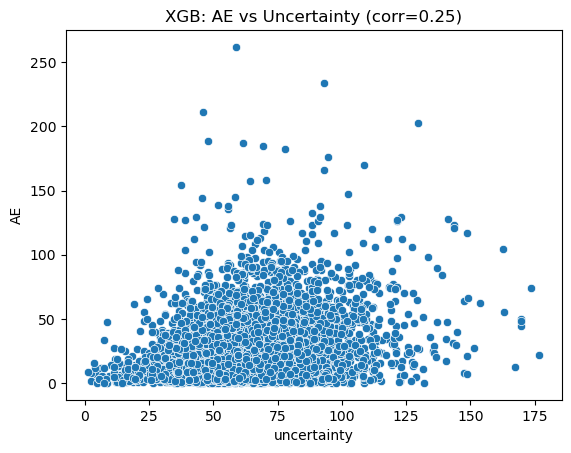

In [10]:
plot_uncertainty_vs_ae(LGB_results, 'XGB')
